In [307]:
import numpy as np
import math
import pandas as pd
from pathlib import Path
from joblib import Parallel, delayed
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

PAPER_DIR = Path(r"E:\PAPER")

code_dir = PAPER_DIR / "code"
data_dir = PAPER_DIR / "data"
fig_dir = PAPER_DIR / "figures"
paper_dir = PAPER_DIR / "paper"

data_generation_code_dir = code_dir / "data_generation"
plotting_code_dir = code_dir / "plotting"

kerr_data_dir = data_dir / "kerr"
kerr_data_error_analysis_dir = data_dir / "error_analysis"
kerr_critical_curves_data_dir = kerr_data_dir / "critical_curves"
kerr_critical_quantities_data_dir = kerr_data_dir / "critical_quantities"
kerr_trajectories_data_dir = kerr_data_dir / "trajectories"
kerr_critical_trajectories_data_dir = kerr_data_dir / "critical_trajectories"
kerr_critical_curves_data_dir_ivp = kerr_critical_curves_data_dir / "IVP"

quasi_kerr_data_dir = data_dir / "quasi_kerr"
quasi_kerr_critical_curves_data_dir = quasi_kerr_data_dir / "critical_curves"
quasi_kerr_critical_quantities_data_dir = quasi_kerr_data_dir / "critical_quantities"
quasi_kerr_trajectories_data_dir = quasi_kerr_data_dir / "trajectories"
quasi_kerr_critical_trajectories_data_dir = quasi_kerr_data_dir / "critical_trajectories"
qk_testing_data_dir = quasi_kerr_data_dir / "testing"

kerr_fig_dir = fig_dir / "kerr"
quasi_kerr_fig_dir = fig_dir / "quasi_kerr"
kerr_fig_critical_curve = kerr_fig_dir / "Critical_Curves"
kerr_fig_r_t = kerr_fig_dir / "R(t)"
kerr_fig_theta_t = kerr_fig_dir / "Theta(t)"
kerr_fig_phi_t = kerr_fig_dir / "Phi(t)"

paper_drafts_dir = paper_dir / "drafts"
paper_figure_dir = paper_dir / "final_figures"

In [183]:
def filename_tag(metric, a, theta_obs_deg, ptheta0=None, epsilon_qk=None):

    tag = f"{metric}_a_{a:.2f}_inc_{theta_obs_deg:.1f}"
    
    # Only add epsilon for quasi-Kerr data
    if metric == 'quasi_kerr':
        tag += f"_eps_{epsilon_qk:+.2f}"
        
    # Only add ptheta for individual trajectory files
    if ptheta0 is not None:
        tag += f"_ptheta_{ptheta0:+.2f}"
    
    return tag

In [355]:
# ============================================================
# Parameters
# ============================================================

a = 0.98
theta_obs_deg = 90.0
theta_obs = np.deg2rad(theta_obs_deg)
M = 1

metric = "kerr"
sampling_tag = "fixed_b"


# ============================================================
# Critical trajectory file
# ============================================================

tag = filename_tag(metric=metric, a=a, theta_obs_deg=theta_obs_deg)

#critical_file = (kerr_critical_trajectories_data_dir / f"Critical_Data_{sampling_tag}_{tag}.csv")
critical_file = (kerr_critical_trajectories_data_dir / f"Critical_Data_{sampling_tag}_{tag}_rtol_-8_atol_-10.csv")

print("Loading:")
print(critical_file)

df_crit_all = pd.read_csv(critical_file)

Loading:
E:\PAPER\data\kerr\critical_trajectories\Critical_Data_fixed_b_kerr_a_0.98_inc_90.0_rtol_-8_atol_-10.csv


In [159]:
def kerr_plot_r_t(df_crit_all, a, sampling_tag, theta_obs_deg, zoom=False, save=False):

    M = 1.0

    # ========================================================
    # Group rays by sampling method
    # ========================================================

    if sampling_tag == "fixed_ptheta":

        ray_groups = list(df_crit_all.groupby(["ptheta", "direction"]))
    
    elif sampling_tag == "fixed_b":
    
        ray_groups = list(df_crit_all.groupby(["b", "ptheta"]))
    
    elif sampling_tag == "fixed_psi":
    
        ray_groups = list(df_crit_all.groupby(["psi"]))
    
    else:
        raise ValueError("sampling_tag must be 'fixed_ptheta', 'fixed_b', or 'fixed_psi'")

    # ========================================================
    # Image-plane angles
    # ========================================================

    psi_values = []

    for _, ray in ray_groups:

        alpha = ray["alpha"].iloc[0]
        beta = ray["beta"].iloc[0]

        psi = np.arctan2(beta, alpha)

        psi_values.append(psi)

    psi_values = np.asarray(psi_values)


    # ========================================================
    # Color map
    # ========================================================

    cmap = plt.get_cmap("plasma")

    norm = mcolors.Normalize(vmin=0, vmax=2 * np.pi)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    
    sm.set_array([])

    # ========================================================
    # Plot
    # ========================================================

    fig, ax = plt.subplots(figsize=(7, 5))

    psi_values = []

    for _, ray in ray_groups:

        ray = ray.sort_values("t")

        t = ray["t"].to_numpy()
        r = ray["r"].to_numpy()

        mask = (np.isfinite(t) & np.isfinite(r) & (np.abs(r) < 1e3))

        t = t[mask]
        r = r[mask]

        alpha = ray["alpha"].iloc[0]
        beta = ray["beta"].iloc[0]

        psi = np.arctan2(beta, alpha) % (2 * np.pi)
        
        psi_values.append(psi)

        color = cmap(norm(psi))

        ax.plot(t, r, color=color, linewidth=1.0)
        
    psi_values = np.asarray(psi_values)
    # ========================================================
    # Event horizon
    # ========================================================

    r_plus = M + np.sqrt(M**2 - a**2)

    ax.axhline(r_plus, color="blue", linestyle="--", linewidth=2 )

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_ticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    
    cbar.set_ticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    
    cbar.set_label(r"$\psi$")
    
    for psi in psi_values:
        cbar.ax.hlines(psi, xmin=0, xmax=1, colors="white", linewidth=1.0, transform=cbar.ax.get_yaxis_transform())

    # ========================================================
    # Zoom
    # ========================================================

    if zoom:

        ax.set_ylim(r_plus - 1, 5)

        zoom_tag = "_zoom"

    else:

        ax.set_ylim(0, 42)

        zoom_tag = ""


    # ========================================================
    # Labels
    # ========================================================

    legend_elements = [Line2D([0], [0], color="blue", lw=2, linestyle="--", label="Event horizon")]

    ax.legend(handles=legend_elements)

    ax.set_xlabel(r"$t/M$")
    ax.set_ylabel(r"$r/M$")

    ax.set_title(rf"Critical Orbit $r(t)$, $a={a:.2f}$")

    # ========================================================
    # Save
    # ========================================================

    if save:

        fig_filename = (kerr_fig_r_t / f"Kerr_Critical_Orbit_r_t_{sampling_tag}"f"_a_{a:.2f}_inc_{theta_obs_deg:.1f}{zoom_tag}.png")

        fig.savefig(fig_filename, dpi=300, bbox_inches="tight")

        print("Saved:", fig_filename)

    plt.show()

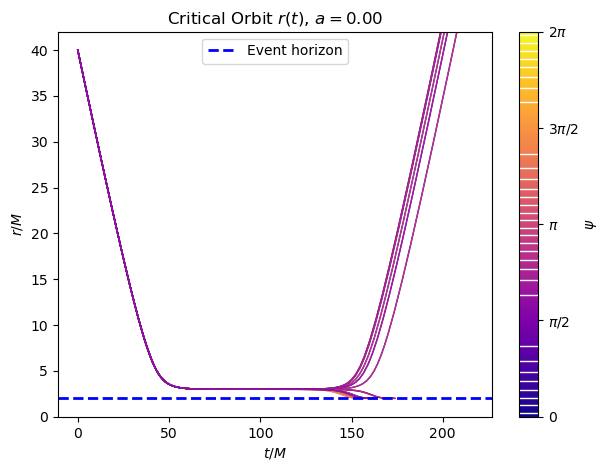

In [255]:
kerr_plot_r_t(df_crit_all, a, sampling_tag, theta_obs_deg, zoom = False)

In [233]:
def kerr_plot_theta_t(df_crit_all, a, sampling_tag, theta_obs_deg, n_rays = 8, save=False):

    M = 1.0

    # ========================================================
    # Group rays by sampling method
    # ========================================================

    if sampling_tag == "fixed_ptheta":

        ray_groups = list(df_crit_all.groupby(["ptheta", "direction"]))
    
    elif sampling_tag == "fixed_b":
    
        ray_groups = list(df_crit_all.groupby(["b", "ptheta"]))
    
    elif sampling_tag == "fixed_psi":
    
        ray_groups = list(df_crit_all.groupby(["psi"]))
    
    else:
        raise ValueError("sampling_tag must be 'fixed_ptheta', 'fixed_b', or 'fixed_psi'")

    # ========================================================
    # Image-plane angles
    # ========================================================

    psi_values = []
    rays_with_psi = []

    for _, ray in ray_groups:

        alpha = ray["alpha"].iloc[0]
        beta = ray["beta"].iloc[0]

        psi = np.arctan2(beta, alpha)% (2 * np.pi)

        psi_values.append(psi)
        rays_with_psi.append((psi, ray))

    psi_values = np.asarray(psi_values)

    target_psi = np.linspace(0, 2*np.pi, n_rays, endpoint=False)
    selected_rays = []

    for target in target_psi:

        distances = []
    
        for psi, ray in rays_with_psi:
    
            diff = abs(psi - target)
            angular_distance = min(diff, 2 * np.pi - diff)
    
            distances.append(angular_distance)
    
        idx = np.argmin(distances)
    
        selected_rays.append(rays_with_psi[idx])

    # ========================================================
    # Color map
    # ========================================================

    cmap = plt.get_cmap("plasma")

    norm = mcolors.Normalize(vmin=0, vmax=2 * np.pi)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    
    sm.set_array([])

    # ========================================================
    # Plot
    # ========================================================

    fig, ax = plt.subplots(figsize=(7, 5))

    psi_values = []

    for psi, ray in selected_rays:

        ray = ray.sort_values("t")

        t = ray["t"].to_numpy()
        r = ray["r"].to_numpy()
        theta = ray["th"].to_numpy()

        mask = (np.isfinite(t) & np.isfinite(r) & (np.abs(r) < 1e3))

        t = t[mask]
        theta = theta[mask]

        alpha = ray["alpha"].iloc[0]
        beta = ray["beta"].iloc[0]

        color = cmap(norm(psi))

        ax.plot(t, theta, color=color, linewidth=1.0)

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_ticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    
    cbar.set_ticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    
    cbar.set_label(r"$\psi$")
    
    for psi, ray in selected_rays:
        cbar.ax.hlines(psi, xmin=0, xmax=1, colors="white", linewidth=1.0, transform=cbar.ax.get_yaxis_transform())

    # ========================================================
    # Labels
    # ========================================================

    ax.set_xlabel(r"$t/M$")
    ax.set_ylabel(r"$\theta$")

    ax.set_yticks([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_yticklabels([r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
    ax.set_ylim(0, np.pi)

    ax.set_title(rf"Critical Orbit $\theta(t)$, $a={a:.2f}$")

    # ========================================================
    # Save
    # ========================================================

    if save:

        fig_filename = (kerr_fig_theta_t / f"Kerr_Critical_Orbit_theta_t_{sampling_tag}"f"_a_{a:.2f}_inc_{theta_obs_deg:.1f}.png")

        fig.savefig(fig_filename, dpi=300, bbox_inches="tight")

        print("Saved:", fig_filename)

    plt.show()

Saved: E:\PAPER\figures\kerr\Theta(t)\Kerr_Critical_Orbit_theta_t_fixed_psi_a_0.98_inc_90.0.png


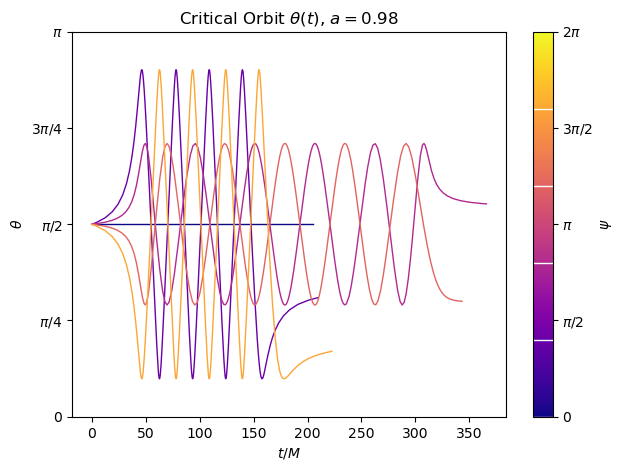

In [305]:
n_rays = 5
kerr_plot_theta_t(df_crit_all, a, sampling_tag, theta_obs_deg, n_rays, save = True)

In [321]:
def kerr_plot_phi_t(df_crit_all, a, sampling_tag, theta_obs_deg, n_rays = 8, save=False):

    M = 1.0

    # ========================================================
    # Group rays by sampling method
    # ========================================================

    if sampling_tag == "fixed_ptheta":

        ray_groups = list(df_crit_all.groupby(["ptheta", "direction"]))
    
    elif sampling_tag == "fixed_b":
    
        ray_groups = list(df_crit_all.groupby(["b", "ptheta"]))
    
    elif sampling_tag == "fixed_psi":
    
        ray_groups = list(df_crit_all.groupby(["psi"]))
    
    else:
        raise ValueError("sampling_tag must be 'fixed_ptheta', 'fixed_b', or 'fixed_psi'")

    # ========================================================
    # Image-plane angles
    # ========================================================

    psi_values = []
    rays_with_psi = []

    for _, ray in ray_groups:

        alpha = ray["alpha"].iloc[0]
        beta = ray["beta"].iloc[0]

        psi = np.arctan2(beta, alpha)% (2 * np.pi)

        psi_values.append(psi)
        rays_with_psi.append((psi, ray))

    psi_values = np.asarray(psi_values)

    target_psi = np.linspace(0, 2*np.pi, n_rays, endpoint=False)
    selected_rays = []

    for target in target_psi:

        distances = []
    
        for psi, ray in rays_with_psi:
    
            diff = abs(psi - target)
            angular_distance = min(diff, 2 * np.pi - diff)
    
            distances.append(angular_distance)
    
        idx = np.argmin(distances)
    
        selected_rays.append(rays_with_psi[idx])

    # ========================================================
    # Color map
    # ========================================================

    cmap = plt.get_cmap("plasma")

    norm = mcolors.Normalize(vmin=0, vmax=2 * np.pi)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    
    sm.set_array([])

    # ========================================================
    # Plot
    # ========================================================

    fig, ax = plt.subplots(figsize=(7, 5))

    psi_values = []

    for psi, ray in selected_rays:

        ray = ray.sort_values("t")

        t = ray["t"].to_numpy()
        r = ray["r"].to_numpy()
        phi = ray["phi"].to_numpy()

        mask = (np.isfinite(t) & np.isfinite(r) & (np.abs(r) < 1e3))

        t = t[mask]
        phi = phi[mask]

        alpha = ray["alpha"].iloc[0]
        beta = ray["beta"].iloc[0]

        color = cmap(norm(psi))

        ax.plot(t, phi, color=color, linewidth=1.0)

    cbar = fig.colorbar(sm, ax=ax)

    cbar.set_ticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    
    cbar.set_ticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    
    cbar.set_label(r"$\psi$")
    
    for psi, ray in selected_rays:
        cbar.ax.hlines(psi, xmin=0, xmax=1, colors="white", linewidth=1.0, transform=cbar.ax.get_yaxis_transform())

    # ========================================================
    # Labels
    # ========================================================

    ax.set_xlabel(r"$t/M$")
    ax.set_ylabel(r"$\phi$ (unwrapped)")

    ax.set_title(rf"Critical Orbit $\phi(t)$, $a={a:.2f}$")

    # ========================================================
    # Save
    # ========================================================

    if save:

        fig_filename = (kerr_fig_phi_t / f"Kerr_Critical_Orbit_phi_t_{sampling_tag}"f"_a_{a:.2f}_inc_{theta_obs_deg:.1f}.png")

        fig.savefig(fig_filename, dpi=300, bbox_inches="tight")

        print("Saved:", fig_filename)

    plt.show()

Saved: E:\PAPER\figures\kerr\Phi(t)\Kerr_Critical_Orbit_phi_t_fixed_b_a_0.98_inc_90.0.png


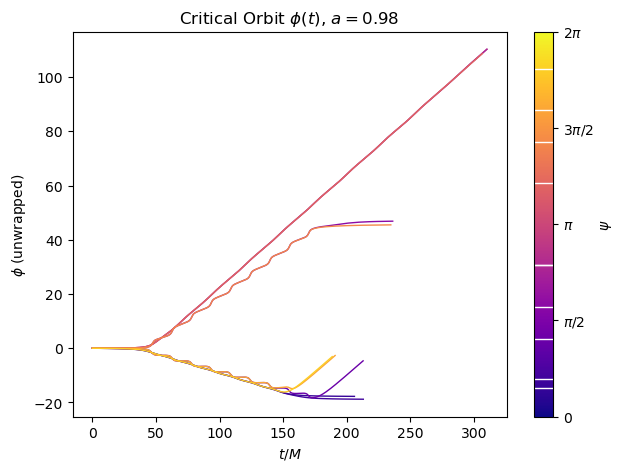

In [357]:
n_rays = 10
kerr_plot_phi_t(df_crit_all, a, sampling_tag, theta_obs_deg, n_rays, save = True)